
      Ad Environment
────────────────────────────────────────
  Ad 00  CTR = 0.144
  Ad 01  CTR = 0.334  ← BEST
  Ad 02  CTR = 0.262
  Ad 03  CTR = 0.218
  Ad 04  CTR = 0.071
  Ad 05  CTR = 0.071
  Ad 06  CTR = 0.039
  Ad 07  CTR = 0.306
  Ad 08  CTR = 0.218
  Ad 09  CTR = 0.254

Simulation complete.


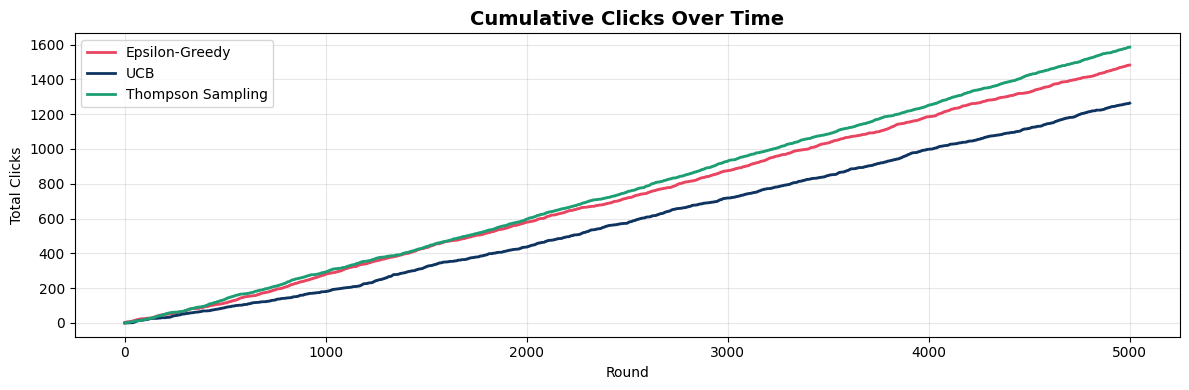

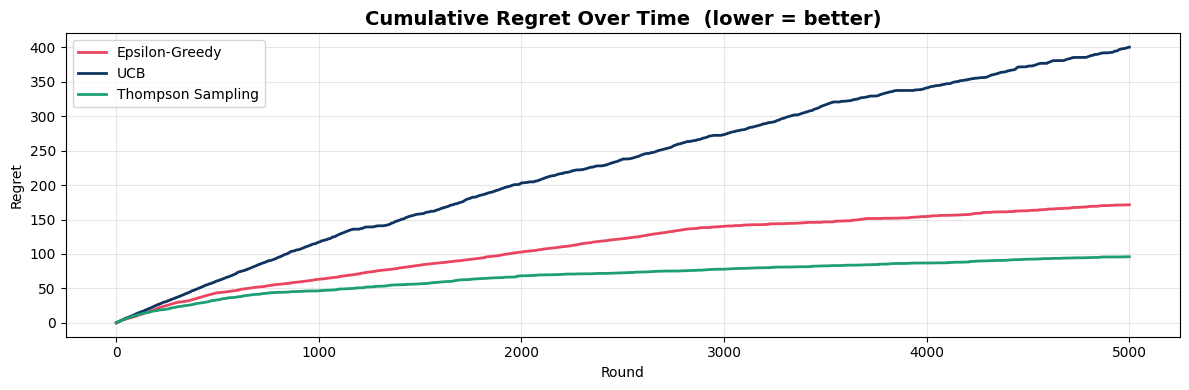

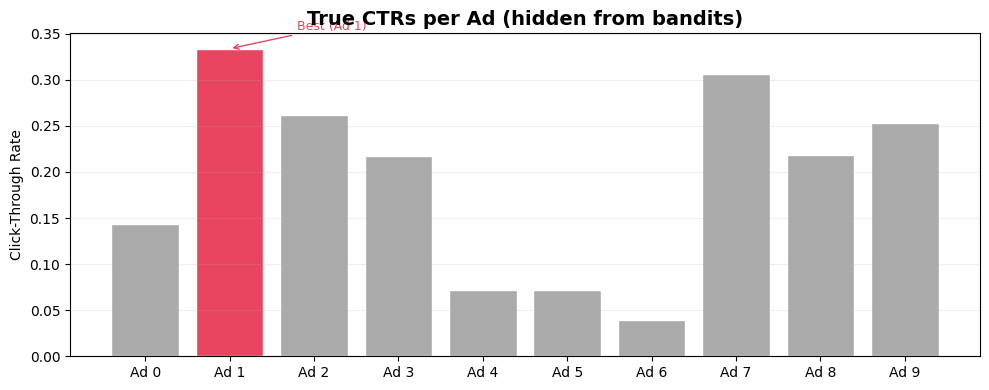

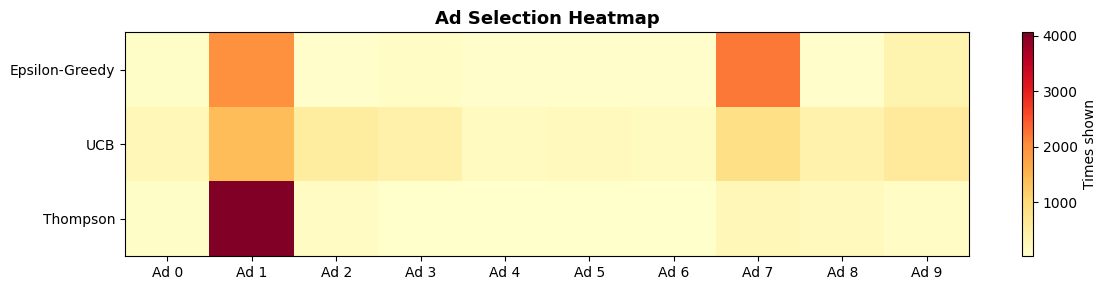


═══════════════════════════════════════════════════════
  FINAL REPORT  —  after 5,000 rounds
═══════════════════════════════════════════════════════
  Best ad (Ad 01) true CTR : 0.334

  Algorithm                   Clicks      CTR     Regret
  ───────────────────────────────────────────────────
  Epsilon-Greedy (ε=0.1)       1,482    0.296      171.3
  UCB                          1,263    0.253      400.1
  Thompson Sampling            1,585    0.317       96.0

  🏆  Lowest regret: Thompson Sampling
═══════════════════════════════════════════════════════



interactive(children=(IntSlider(value=10, description='Ads', max=20, min=3, style=SliderStyle(description_widt…

<function __main__.run_interactive(n_ads, n_rounds, epsilon, ucb_c, seed)>

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
%matplotlib inline

from environment import AdEnvironment
from bandits import EpsilonGreedy, UCB, ThompsonSampling
from simulation import run_simulation, print_report

# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────

N_ADS    = 10
N_ROUNDS = 5000
SEED     = 42

NAMES  = ["Epsilon-Greedy", "UCB", "Thompson Sampling"]
COLORS = ["#E94560", "#0F3460", "#1D9E75"]

# ─────────────────────────────────────────────
# ENVIRONMENT PREVIEW
# ─────────────────────────────────────────────

env = AdEnvironment(n_ads=N_ADS, seed=SEED)
env.summary()

# ─────────────────────────────────────────────
# RUN SIMULATION
# ─────────────────────────────────────────────

bandits = [
    EpsilonGreedy(N_ADS, epsilon=0.1),
    UCB(N_ADS, c=2.0),
    ThompsonSampling(N_ADS),
]

all_rewards = []
all_regrets = []
all_counts  = []

for bandit in bandits:
    rewards, regrets, counts = run_simulation(bandit, env, N_ROUNDS)
    all_rewards.append(rewards)
    all_regrets.append(regrets)
    all_counts.append(counts)

print("Simulation complete.")

# ─────────────────────────────────────────────
# CHART 1 — CUMULATIVE CLICKS
# ─────────────────────────────────────────────

rounds = range(1, N_ROUNDS + 1)

plt.figure(figsize=(12, 4))
for i, (name, rewards) in enumerate(zip(NAMES, all_rewards)):
    plt.plot(rounds, rewards, label=name, color=COLORS[i], linewidth=2)
plt.title("Cumulative Clicks Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Round")
plt.ylabel("Total Clicks")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# CHART 2 — CUMULATIVE REGRET
# ─────────────────────────────────────────────

plt.figure(figsize=(12, 4))
for i, (name, regrets) in enumerate(zip(NAMES, all_regrets)):
    plt.plot(rounds, regrets, label=name, color=COLORS[i], linewidth=2)
plt.title("Cumulative Regret Over Time  (lower = better)", fontsize=14, fontweight='bold')
plt.xlabel("Round")
plt.ylabel("Regret")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# CHART 3 — TRUE CTRs
# ─────────────────────────────────────────────

bar_colors = ["#E94560" if i == env.best_ad else "#AAAAAA" for i in range(N_ADS)]

plt.figure(figsize=(10, 4))
plt.bar(range(N_ADS), env.true_ctrs, color=bar_colors, edgecolor='white')
plt.xticks(range(N_ADS), [f"Ad {i}" for i in range(N_ADS)])
plt.title("True CTRs per Ad (hidden from bandits)", fontsize=14, fontweight='bold')
plt.ylabel("Click-Through Rate")
plt.annotate(
    f"Best (Ad {env.best_ad})",
    xy=(env.best_ad, env.best_ctr),
    xytext=(env.best_ad + 0.8, env.best_ctr + 0.02),
    fontsize=9, color="#E94560",
    arrowprops=dict(arrowstyle="->", color="#E94560")
)
plt.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# CHART 4 — AD SELECTION HEATMAP
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 3))
matrix = np.array(all_counts)
im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(N_ADS))
ax.set_xticklabels([f"Ad {i}" for i in range(N_ADS)])
ax.set_yticks(range(len(bandits)))
ax.set_yticklabels([b.name.split(" ")[0] for b in bandits])
ax.set_title("Ad Selection Heatmap", fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label="Times shown")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# FINAL REPORT
# ─────────────────────────────────────────────

print_report(env, bandits, all_rewards, all_regrets, all_counts, N_ROUNDS)

# ─────────────────────────────────────────────
# INTERACTIVE DASHBOARD (sliders)
# ─────────────────────────────────────────────

def run_interactive(n_ads, n_rounds, epsilon, ucb_c, seed):
    env = AdEnvironment(n_ads=n_ads, seed=seed)

    bandits = [
        EpsilonGreedy(n_ads, epsilon=epsilon),
        UCB(n_ads, c=ucb_c),
        ThompsonSampling(n_ads),
    ]

    all_rewards, all_regrets, all_counts = [], [], []
    for b in bandits:
        r, reg, c = run_simulation(b, env, n_rounds)
        all_rewards.append(r)
        all_regrets.append(reg)
        all_counts.append(c)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    rounds = range(1, n_rounds + 1)

    for i, (name, rewards) in enumerate(zip(NAMES, all_rewards)):
        axes[0].plot(rounds, rewards, label=name, color=COLORS[i], linewidth=2)
    axes[0].set_title("Cumulative Clicks")
    axes[0].set_xlabel("Round")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    for i, (name, regrets) in enumerate(zip(NAMES, all_regrets)):
        axes[1].plot(rounds, regrets, label=name, color=COLORS[i], linewidth=2)
    axes[1].set_title("Cumulative Regret  (lower = better)")
    axes[1].set_xlabel("Round")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"Ads: {n_ads}  |  Rounds: {n_rounds}  |  Seed: {seed}",
                 fontsize=11, color='gray')
    plt.tight_layout()
    plt.show()

    print_report(env, bandits, all_rewards, all_regrets, all_counts, n_rounds)


widgets.interact(
    run_interactive,
    n_ads    = widgets.IntSlider(min=3,   max=20,    value=10,   step=1,   description="Ads",     style={'description_width': '80px'}),
    n_rounds = widgets.IntSlider(min=500, max=10000, value=5000, step=500, description="Rounds",  style={'description_width': '80px'}),
    epsilon  = widgets.FloatSlider(min=0.01, max=0.5, value=0.1, step=0.01, description="Epsilon", style={'description_width': '80px'}),
    ucb_c    = widgets.FloatSlider(min=0.5, max=5.0, value=2.0,  step=0.1,  description="UCB c",   style={'description_width': '80px'}),
    seed     = widgets.IntSlider(min=1,   max=100,   value=42,   step=1,   description="Seed",    style={'description_width': '80px'}),
)